In [ ]:
# Testen von ManifestoBERTa

# Modell wurde speziell für politische Texte trainiert 

In [ ]:
# standard versuch von ManifestoBerta als vergleich.
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-large")

sentence = "These principles are under threat."
context = "Human rights and international humanitarian law are fundamental pillars of a secure global system. These principles are under threat. Some of the world's most powerful states choose to sell arms to human-rights abusing states."
# For sentences without additional context, just use the sentence itself as the context.
# Example: context = "These principles are under threat."


inputs = tokenizer(sentence,
                   context,
                   return_tensors="pt",
                   max_length=512,  #we limited the input to 300 tokens during finetuning
                   padding="max_length",
                   truncation=True
                   )

logits = model(**inputs).logits

probabilities = torch.softmax(logits, dim=1).tolist()[0]
probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
print(probabilities)
# {'201 - Freedom and Human Rights': 86.58, '107 - Internationalism: Positive': 8.12, '106 - Peace': 1.67...

predicted_class = model.config.id2label[logits.argmax().item()]
print(predicted_class)
# 201 - Freedom and Human Rights


A new version of the following files was downloaded from https://huggingface.co/manifesto-project/manifestoberta-xlm-roberta-56policy-topics-context-2024-1-1:
- modeling_custom_head_xlm_roberta.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


{'201 - Freedom and Human Rights': 86.58, '107 - Internationalism: Positive': 8.12, '106 - Peace': 1.67, '105 - Military: Negative': 1.01, '202 - Democracy': 0.47, '104 - Military: Positive': 0.43, '103 - Anti-Imperialism': 0.39, '109 - Internationalism: Negative': 0.19, '305 - Political Authority': 0.19, '605 - Law and Order: Positive': 0.17, '203 - Constitutionalism: Positive': 0.07, '602 - National Way of Life: Negative': 0.07, '603 - Traditional Morality: Positive': 0.06, '503 - Equality: Positive': 0.05, '601 - National Way of Life: Positive': 0.05, '416 - Anti-Growth Economy: Positive': 0.04, '501 - Environmental Protection: Positive': 0.04, '101 - Foreign Special Relationships: Positive': 0.03, '403 - Market Regulation': 0.03, '604 - Traditional Morality: Negative': 0.03, '606 - Civic Mindedness: Positive': 0.03, '102 - Foreign Special Relationships: Negative': 0.02, '108 - European Community/Union: Positive': 0.02, '406 - Protectionism: Positive': 0.02, '504 - Welfare State Exp

In [4]:
# versuch mit SPD Text 

sentence = "Wir wollen, dass Deine Arbeit auch in der Rente ihren Wert behält."
context = "Wir sorgen dafür, dass das Niveau der gesetzlichen Rentenversicherung dauerhaft bei mindestens 48 Prozent gesichert wird. Eine Anhebung der Regelaltersgrenze lehnen wir ab. Abschlagsfreier Renteneintritt bleibt nach 45 Jahren möglich."
# For sentences without additional context, just use the sentence itself as the context.
# Example: context = "These principles are under threat."


inputs = tokenizer(sentence,
                   context,
                   return_tensors="pt",
                   max_length=512,  #we limited the input to 300 tokens during finetuning
                   padding="max_length",
                   truncation=True
                   )

logits = model(**inputs).logits

probabilities = torch.softmax(logits, dim=1).tolist()[0]
probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
print(probabilities)
# {'201 - Freedom and Human Rights': 86.58, '107 - Internationalism: Positive': 8.12, '106 - Peace': 1.67...

predicted_class = model.config.id2label[logits.argmax().item()]
print(predicted_class)

{'504 - Welfare State Expansion': 61.46, '701 - Labour Groups: Positive': 31.58, '503 - Equality: Positive': 2.08, '505 - Welfare State Limitation': 1.97, '704 - Middle Class and Professional Groups': 0.42, '408 - Economic Goals': 0.33, '606 - Civic Mindedness: Positive': 0.31, '412 - Controlled Economy': 0.28, '401 - Free Market Economy': 0.24, '706 - Non-economic Demographic Groups': 0.19, '303 - Governmental and Administrative Efficiency': 0.17, '201 - Freedom and Human Rights': 0.09, '403 - Market Regulation': 0.09, '305 - Political Authority': 0.08, '402 - Incentives': 0.07, '414 - Economic Orthodoxy': 0.07, '601 - National Way of Life: Positive': 0.07, '603 - Traditional Morality: Positive': 0.07, '410 - Economic Growth: Positive': 0.06, '411 - Technology and Infrastructure': 0.04, '405 - Corporatism/ Mixed Economy': 0.03, '506 - Education Expansion': 0.03, '702 - Labour Groups: Negative': 0.03, '705 - Underprivileged Minority Groups': 0.03, '404 - Economic Planning': 0.02, '416 

In [ ]:
# Mapping von Policy-Kategorien zu Wahlomat-Positionen
policy_to_wahlomat = {
    "504 - Welfare State Expansion": "Stimme zu",   # Sozialstaat stärken
    "505 - Welfare State Limitation": "Stimme nicht zu",  # Sozialstaat abbauen
    "701 - Labour Groups: Positive": "Stimme zu",   # Arbeitnehmerfreundlich
    "702 - Labour Groups: Negative": "Stimme nicht zu",  # Arbeitnehmer unfreundlich
}

def map_policy_to_wahlomat(predictions):
    """
    Wandelt die Policy-Kategorien des Modells in Wahlomat-Antworten um.
    """
    if not predictions:
        return "Neutral"  # Falls keine Vorhersage vorhanden ist

    # Sortiere die Predictions nach Wahrscheinlichkeit (höchster Wert zuerst)
    sorted_predictions = sorted(predictions.items(), key=lambda item: item[1], reverse=True)

    # Wähle die Top-Kategorie
    top_policy = sorted_predictions[0][0]

    # Prüfe, ob die Top-Kategorie im Mapping enthalten ist
    return policy_to_wahlomat.get(top_policy, "Neutral")

# **Beispieldaten von deinem Modell**
probabilities = {
    "504 - Welfare State Expansion": 61.46,
    "701 - Labour Groups: Positive": 31.58,
    "505 - Welfare State Limitation": 1.97,
}

# Mapping auf Wahlomat-Kategorien
wahlomat_antwort = map_policy_to_wahlomat(probabilities)

print(f"Wahlomat-Antwort: {wahlomat_antwort}")


Wahlomat-Antwort: Stimme zu


## Rest hier drunter nur mal als GPT Lauf getestet. Macht so noch nicht Sinn. Texte müssen anders formatiert betrachtet werden. 

In [6]:
import pandas as pd

# Wahlomat-Thesen laden
df_questions = pd.read_csv("wahlomaten_thesen_positionen.csv")

# Liste für Ergebnisse
results = []

for index, row in df_questions.iterrows():
    sentence = row["These"]
    context = sentence  # Falls es keinen extra Kontext gibt, nutze die These selbst

    # Tokenisierung
    inputs = tokenizer(sentence, context, return_tensors="pt", max_length=512, padding="max_length", truncation=True)

    # Modellvorhersage
    logits = model(**inputs).logits
    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    
    # Mapping der ID zur Policy-Kategorie
    probabilities = {model.config.id2label[index]: round(probability * 100, 2) for index, probability in enumerate(probabilities)}
    probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))
    
    # Beste Kategorie wählen
    predicted_class = model.config.id2label[logits.argmax().item()]

    # Speichern der Ergebnisse
    results.append({"These": sentence, "Best_Policy_Category": predicted_class, "Full_Probabilities": probabilities})

# Ergebnisse als DataFrame speichern
df_results = pd.DataFrame(results)
df_results.to_csv("wahlomat_policy_predictions.csv", index=False)

print("✅ Wahlomat-Kategorien gespeichert in 'wahlomat_policy_predictions.csv'")


✅ Wahlomat-Kategorien gespeichert in 'wahlomat_policy_predictions.csv'


In [21]:
# Wahlprogramme laden
df_parties = pd.read_parquet("all_parties_text_combined_prep.parquet")

In [ ]:
# Neue Spalten für das Mapping hinzufügen
df_parties["Policy_Category"] = ""
df_parties["Wahlomat_Answer"] = ""

# Durch alle Partei-Texte iterieren
for index, row in df_parties.iterrows():
    sentence = row["Text"]
    context = sentence  # Falls kein Kontext verfügbar ist, nutze den Text selbst

    # Modell-Vorhersage
    inputs = tokenizer(sentence, context, return_tensors="pt", max_length=512, padding="max_length", truncation=True)
    logits = model(**inputs).logits

    # Wahrscheinlichkeiten berechnen
    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    predicted_class = model.config.id2label[logits.argmax().item()]

    # Wahlomat-Antwort bestimmen
    wahlomat_answer = policy_to_wahlomat.get(predicted_class, "Neutral")

    # Ergebnisse speichern
    df_parties.at[index, "Policy_Category"] = predicted_class
    df_parties.at[index, "Wahlomat_Answer"] = wahlomat_answer

# Ergebnisse speichern
df_parties.to_csv("manifestoberta_wahlomat_predictions.csv", index=False)

print("Partei-Positionen gespeichert in 'manifestoberta_wahlomat_predictions.csv'")


✅ Partei-Positionen gespeichert in 'manifestoberta_wahlomat_predictions.csv'


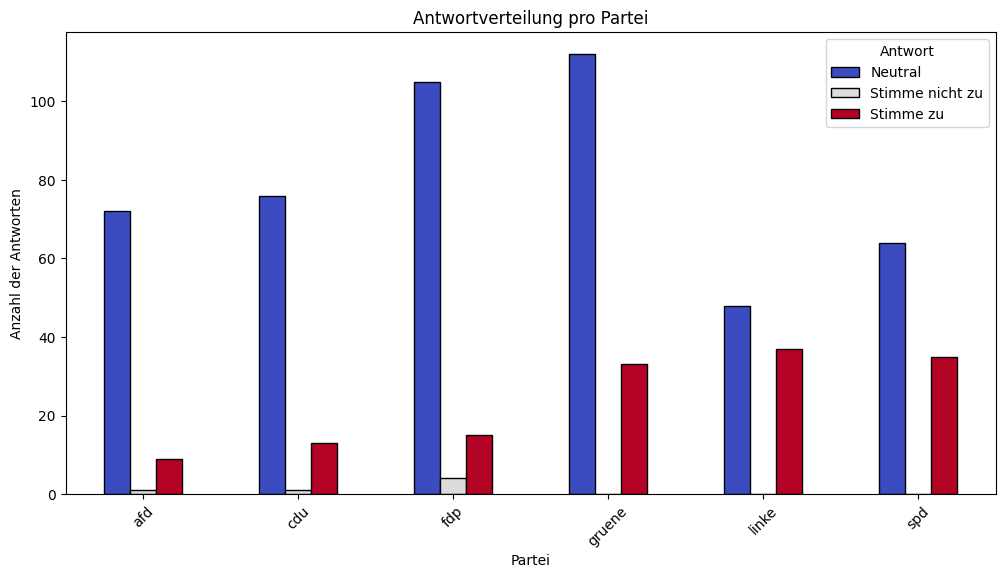

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Ergebnisse laden
df_parties = pd.read_csv("manifestoberta_wahlomat_predictions.csv")

# Zähle die Häufigkeit jeder Wahlomat-Antwort pro Partei
party_counts = df_parties.groupby(["Party", "Wahlomat_Answer"]).size().unstack()

# Balkendiagramm erstellen
party_counts.plot(kind="bar", figsize=(12,6), colormap="coolwarm", edgecolor="black")

plt.title("Antwortverteilung pro Partei")
plt.xlabel("Partei")
plt.ylabel("Anzahl der Antworten")
plt.xticks(rotation=45)
plt.legend(title="Antwort", loc="upper right")
plt.show()


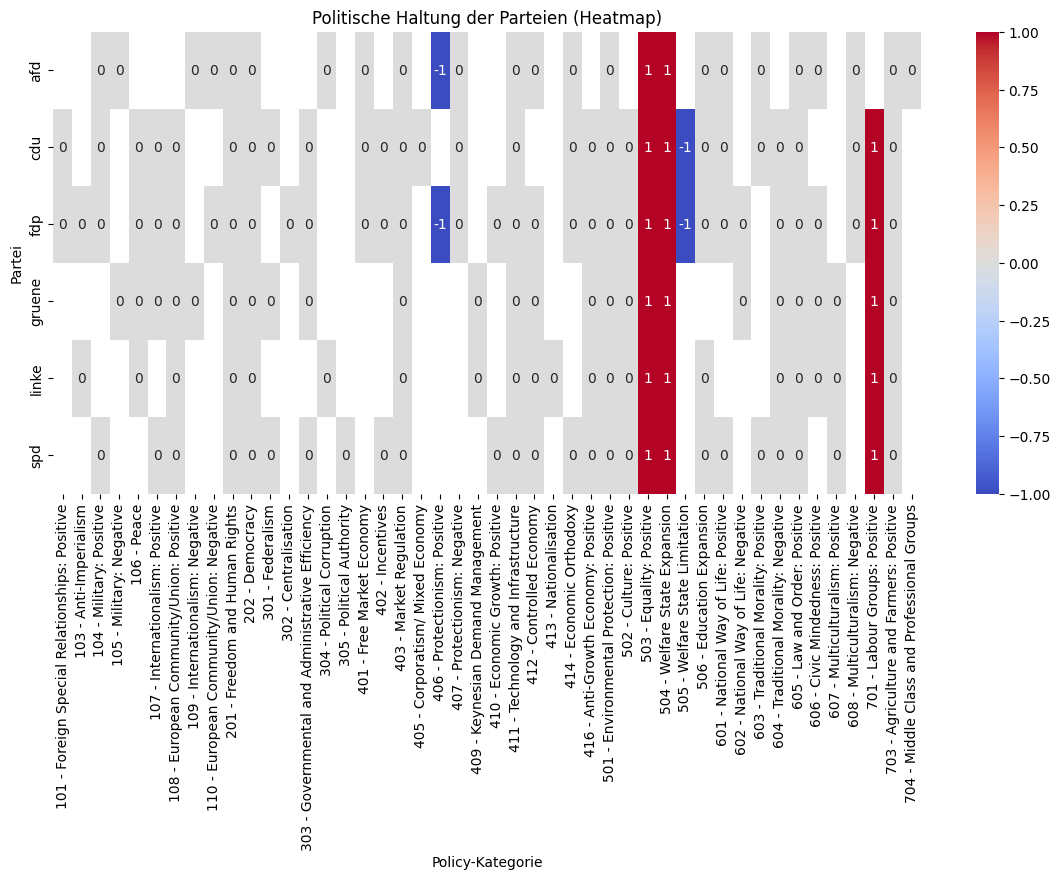

In [24]:
import seaborn as sns

# Wahlomat-Antworten in Zahlen umwandeln
mapping_numeric = {"Stimme nicht zu": -1, "Neutral": 0, "Stimme zu": 1}
df_parties["Wahlomat_Answer_Num"] = df_parties["Wahlomat_Answer"].map(mapping_numeric)

# Pivot-Tabelle: Parteien vs. Policy-Kategorien
heatmap_data = df_parties.pivot_table(index="Party", columns="Policy_Category", values="Wahlomat_Answer_Num", aggfunc="mean")

# Heatmap erstellen
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, center=0)

plt.title("Politische Haltung der Parteien (Heatmap)")
plt.xlabel("Policy-Kategorie")
plt.ylabel("Partei")
plt.show()
